In [1]:
import os

import scipy
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Style and plot settings
plt.style.use("ggplot")

COLOR = "red"
ALPHA_MEAN = 0.9
ALPHA_STD = 0.1
AVG_FILTER_SIZE = 10

In [3]:
def load_data(env_id: str) -> pd.DataFrame:
    files = [x for x in os.listdir() if env_id in x and x.endswith(".csv")]
    dfs = [pd.read_csv(f) for f in files]
    
    df_out = pd.DataFrame() 
    df_out["t"] = dfs[0]["t"]

    stacked_means = pd.concat([df["average_return"] for df in dfs], axis=1)
    df_out["average_return"] = stacked_means.mean(axis=1)  
    df_out["std_return"] = stacked_means.std(axis=1, ddof=1)  

    return df_out

## LunarLander-v3

In [4]:
data = load_data("LunarLander-v3")
data.head(-1)

,t,average_return,std_return
0,6144,-422.450741,265.634840
1,10240,-292.129752,292.219325
2,16384,-274.803436,297.170046
3,20480,-206.494016,283.932932
4,26624,-242.688778,233.483377
...,...,...,...
195,980992,276.636749,7.104611
196,985088,275.472662,4.386760
197,991232,270.463946,10.553086
198,995328,278.078873,3.418742


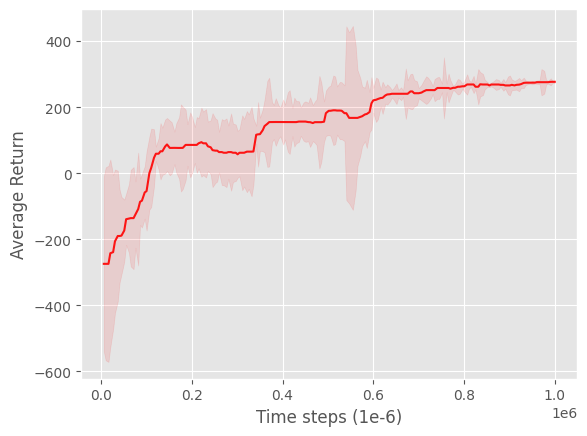

In [5]:
t = data["t"]
mean = data["average_return"]
mean = scipy.ndimage.median_filter(data["average_return"], size=AVG_FILTER_SIZE)
std = data["std_return"]
lower = mean - std
upper = mean + std

fig, ax = plt.subplots()
ax.plot(t, mean, color=COLOR, alpha=ALPHA_MEAN)
ax.fill_between(t, lower, upper, alpha=ALPHA_STD, color=COLOR)
ax.set_xlabel("Time steps (1e-6)")
ax.set_ylabel("Average Return")
plt.show()



## BipedalWalker-v3

In [6]:
data = load_data("BipedalWalker-v3")
data.head(-1)

,t,average_return,std_return
0,6144,-73.993931,37.373816
1,10240,-102.166178,8.468419
2,16384,-48.091800,31.013603
3,20480,-35.778837,3.103651
4,26624,-83.414268,35.316244
...,...,...,...
195,980992,262.699971,14.853089
196,985088,260.672685,18.875437
197,991232,247.870836,14.264688
198,995328,254.004923,28.141734


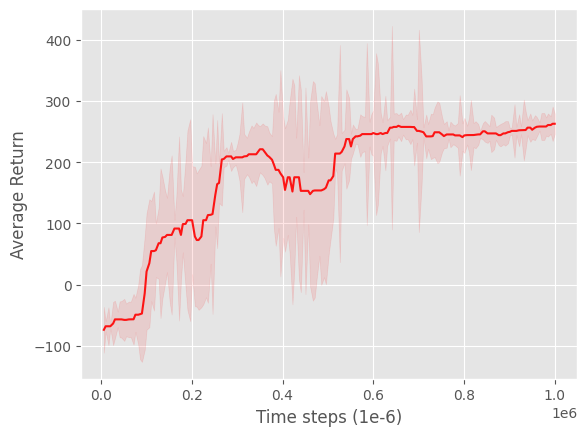

In [7]:
t = data["t"]
mean = data["average_return"]
mean = scipy.ndimage.median_filter(data["average_return"], size=AVG_FILTER_SIZE)
std = data["std_return"]
lower = mean - std
upper = mean + std

fig, ax = plt.subplots()
ax.plot(t, mean, color=COLOR, alpha=ALPHA_MEAN)
ax.fill_between(t, lower, upper, alpha=ALPHA_STD, color=COLOR)
ax.set_xlabel("Time steps (1e-6)")
ax.set_ylabel("Average Return")
plt.show()

